# Exploratory Data Analysis

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bioacoustics.data import load_results, load_metadata

import bioacoustics.visualization as viz

viz.set_style()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
data_train = load_results("features", "data_train")
data_train_soundscapes = load_results("features", "data_train_soundscapes")
_, _, df_taxonomy = load_metadata()
primary_to_class = dict(zip(df_taxonomy["primary_label"], df_taxonomy["class_name"]))

In [31]:
data_train_embeddings = load_results(
    "features", "data_train_soundscapes", subdir="embeddings"
)

Here, analyze collected features (do dimension reduction, etc.). Analyze species presence, class balance...

In [32]:
data_train["X"]

,std,max,min,rms,zcr_mean,zcr_std,zcr_p25,zcr_p50,zcr_p75,rms_frame_mean,...,onset_mean,onset_std,onset_p50,onset_p90,n_onsets,onset_interval_mean,onset_interval_std,onset_interval_p10,onset_interval_p50,onset_interval_p90
filename,,,,,,,,,,,,,,,,,,,,,
1161364/iNat1216197.ogg,0.012937,0.117196,-0.144763,0.012937,0.322851,0.071716,0.334717,0.349854,0.359375,0.012306,...,1.103774,0.884024,1.032598,1.358123,23.5,0.107378,0.072551,0.0480,0.096,0.1760
1161364/iNat1114648.ogg,0.007936,0.046324,-0.051197,0.007936,0.171538,0.047947,0.144775,0.180176,0.203613,0.007785,...,1.056202,0.332621,1.031676,1.324760,25.5,0.296185,0.161824,0.1256,0.228,0.5104
1161364/iNat810195.ogg,0.009831,0.043589,-0.050872,0.009831,0.318269,0.020365,0.307861,0.320557,0.330322,0.009783,...,1.101169,0.263577,1.088763,1.400425,42.0,0.119415,0.066573,0.0416,0.112,0.2040
1161364/iNat818781.ogg,0.077515,0.348526,-0.334061,0.077515,0.294947,0.011699,0.293457,0.295898,0.297852,0.076146,...,1.149691,0.297133,1.133739,1.497493,55.0,0.091556,0.048379,0.0384,0.080,0.1600
1161364/iNat556514.ogg,0.042982,0.183904,-0.178992,0.042982,0.387283,0.018997,0.377441,0.387695,0.397461,0.042866,...,0.969751,0.249014,0.959307,1.205052,31.0,0.155273,0.096002,0.0496,0.136,0.2944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yeofly1/XC762473.ogg,0.062652,0.619118,-0.622950,0.062652,0.399467,0.023129,0.399414,0.406250,0.411133,0.058950,...,0.995263,0.367063,0.952219,1.261574,32.0,0.157419,0.152390,0.0320,0.128,0.3200
yeofly1/XC818328.ogg,0.017479,0.248983,-0.257194,0.017479,0.157337,0.077062,0.112061,0.133545,0.171631,0.010047,...,1.030130,0.755783,0.943722,1.248977,12.0,0.877714,0.061827,0.8080,0.856,0.9760
yeofly1/XC425545.ogg,0.021913,0.414133,-0.411249,0.021913,0.299748,0.028100,0.281006,0.297852,0.312012,0.015076,...,0.992015,0.422510,0.929399,1.246191,26.0,0.180480,0.141311,0.0480,0.160,0.3472


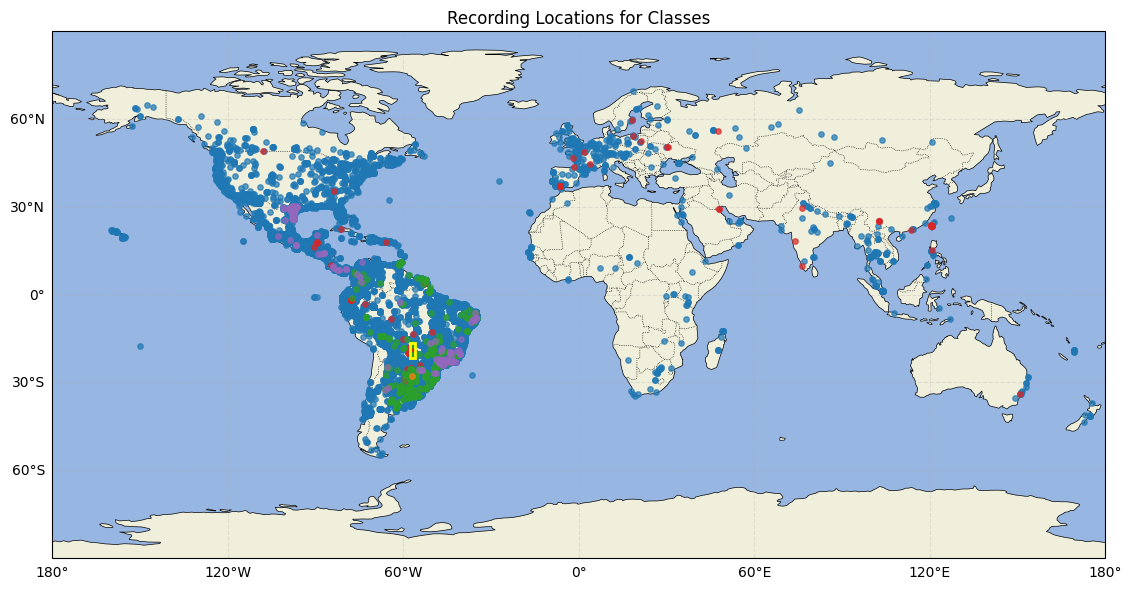

<GeoAxes: title={'center': 'Recording Locations for Classes'}>

In [33]:
viz.plot_location_map(
    data_train
)  # , save_file="../results/figures/train-audio-map.pdf")

Saving...


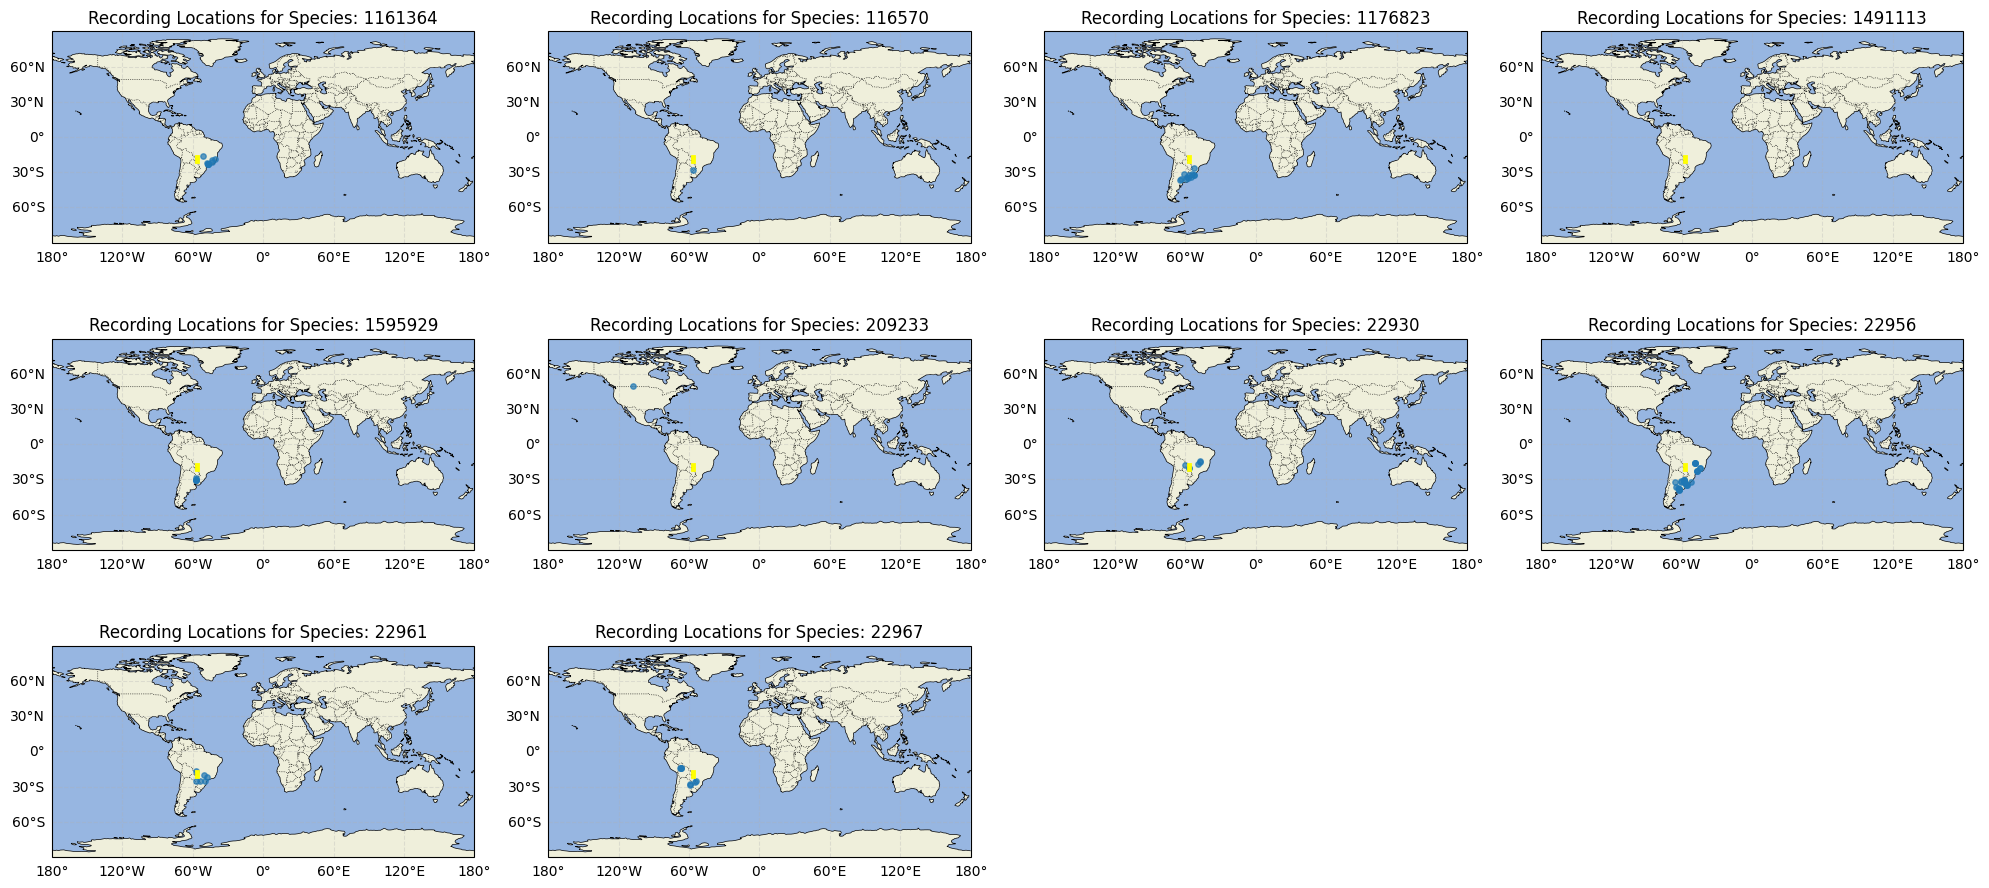

In [34]:
import math
import cartopy.crs as ccrs

species_list = data_train["y_primary"].columns[:10]

# Grid size
n_species = len(species_list)
ncols = 4
nrows = math.ceil(n_species / ncols)

# Create figure with Cartopy subplots
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each species
for ax, species in zip(axes, species_list):
    viz.plot_location_map_species(
        data_train,
        species,
        ax=ax,
    )

# Remove unused axes
for ax in axes[n_species:]:
    fig.delaxes(ax)

fig.tight_layout()
print("Saving...")
fig.savefig("../results/figures/species-map-individuals.pdf")
plt.show()

Distribution of `data_train` and `data_train_soundscapes`

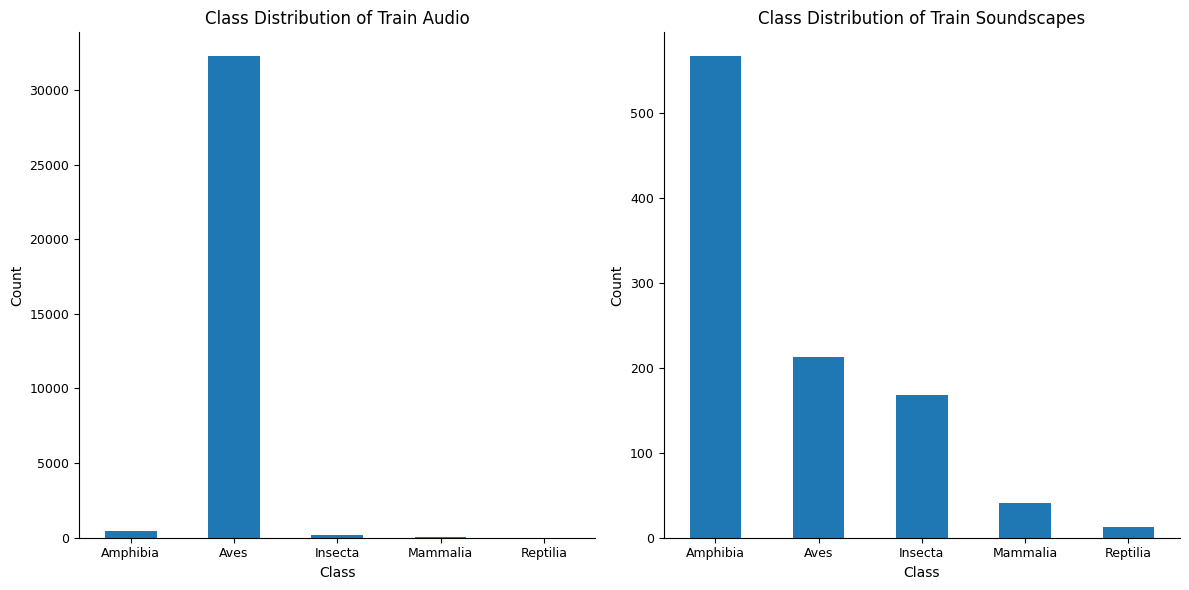

In [35]:
viz.plot_class_distribution(
    data_train,
    data_train_soundscapes,
    save_file="../results/figures/class-distribution.pdf",
)

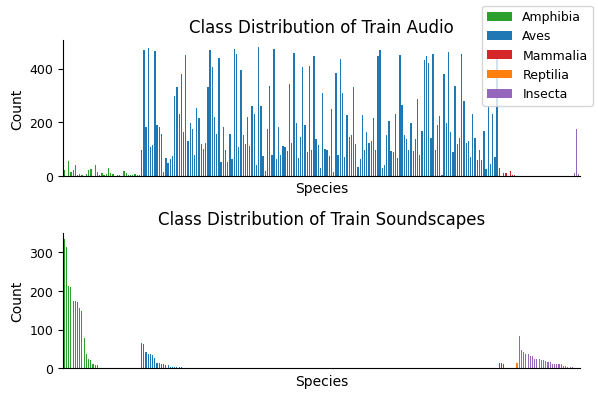

In [36]:
viz.plot_species_distribution(
    data_train["y_primary"].sum(axis=0),
    data_train_soundscapes["y_primary"].sum(axis=0),
    primary_to_class,
    save_file="../results/figures/species-distribution.pdf",
)

We see that the distribution between `train_audio` and `train_soundscapes` is very different, so we need to be careful when we work between them.

Correlation matrix

In [37]:
corr_matrix = data_train_soundscapes["X"].corr()

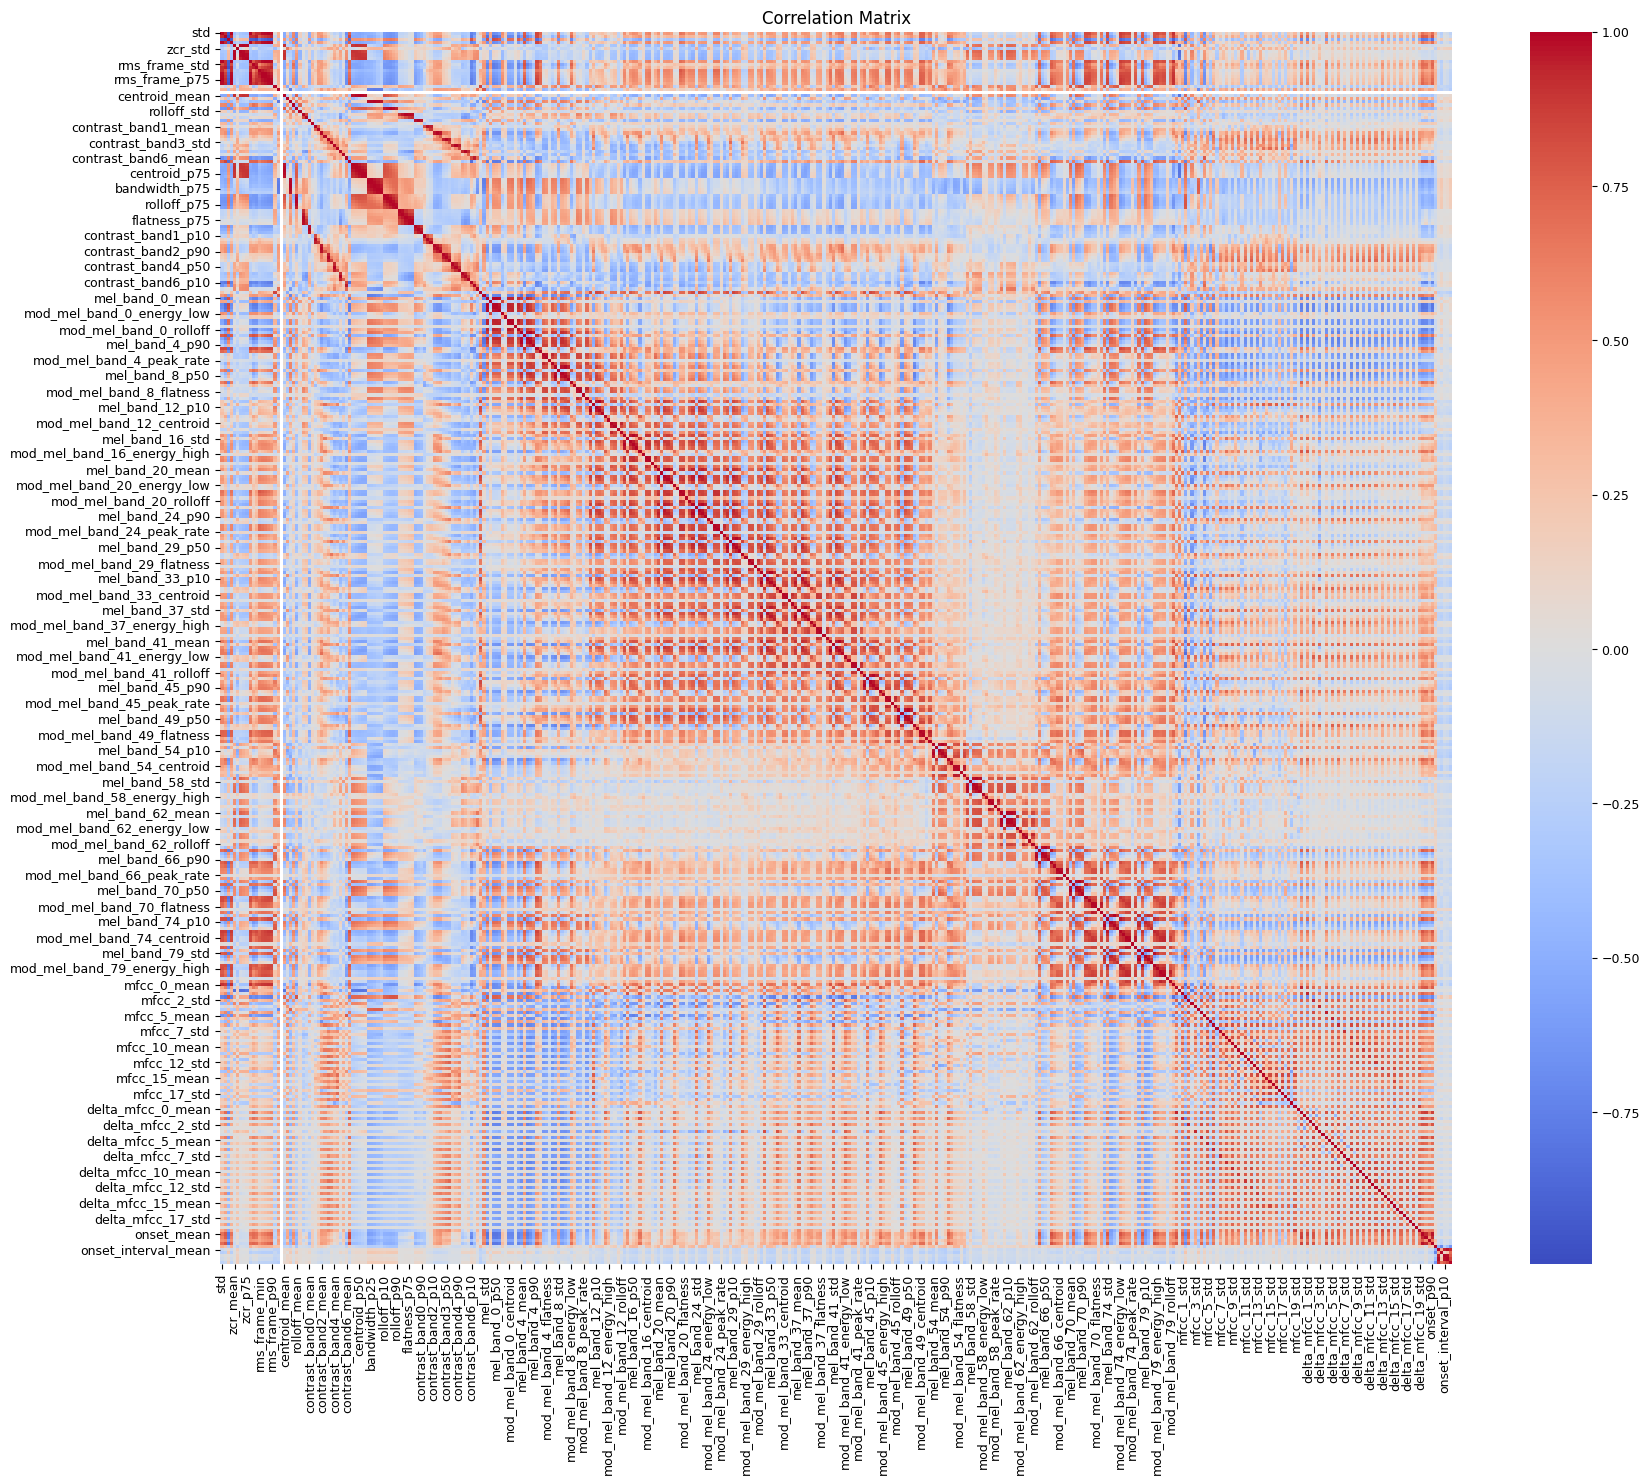

In [38]:
viz.plot_corr_matrix(corr_matrix, save_file="../results/figures/correlation-matrix.pdf")

We can see some "boxes" of high correlation usually around the same type of features (e.g. `mode_mel_band`). Let's let's see what are the most correlated variables

In [39]:
# Flatten correlation matrix into pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs = corr_pairs.dropna()

# Rename columns
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Sort by absolute correlation (strongest first)
corr_pairs = corr_pairs.reindex(
    corr_pairs["correlation"].abs().sort_values(ascending=False).index
)

corr_pairs

,feature_1,feature_2,correlation
3,std,rms,1.000000e+00
33663,mel_band_0_mean,mel_band_0_p50,9.992545e-01
103359,mel_band_66_mean,mel_band_66_p50,9.984048e-01
99003,mel_band_62_mean,mel_band_62_p50,9.983777e-01
1587,zcr_mean,zcr_p50,9.983374e-01
...,...,...,...
140983,delta_mfcc_5_std,delta_mfcc_9_mean,-8.477627e-06
48042,mel_band_12_p50,mod_mel_band_58_flatness,8.200518e-06
10258,rolloff_std,delta_mfcc_19_mean,6.651074e-06
60253,mel_band_24_std,mod_mel_band_45_centroid,4.642253e-06


In [40]:
(corr_pairs["correlation"] > 0.90).sum()

np.int64(432)

We can look into doing something like correlation filtering in order to remove features that are too correlated. Depending on the type of model we use later this can help.

In [41]:
# viz.plot_feature_distribution(data_train_soundscapes, "mean")

It is strange that the means are in such clear bands. This may be an artifact to the different recording stations that may not carry over well into the test dataset.

In [42]:
data_train_soundscapes["X"].columns

Index(['std', 'max', 'min', 'rms', 'zcr_mean', 'zcr_std', 'zcr_p25', 'zcr_p50',
       'zcr_p75', 'rms_frame_mean',
       ...
       'onset_mean', 'onset_std', 'onset_p50', 'onset_p90', 'n_onsets',
       'onset_interval_mean', 'onset_interval_std', 'onset_interval_p10',
       'onset_interval_p50', 'onset_interval_p90'],
      dtype='str', length=395)

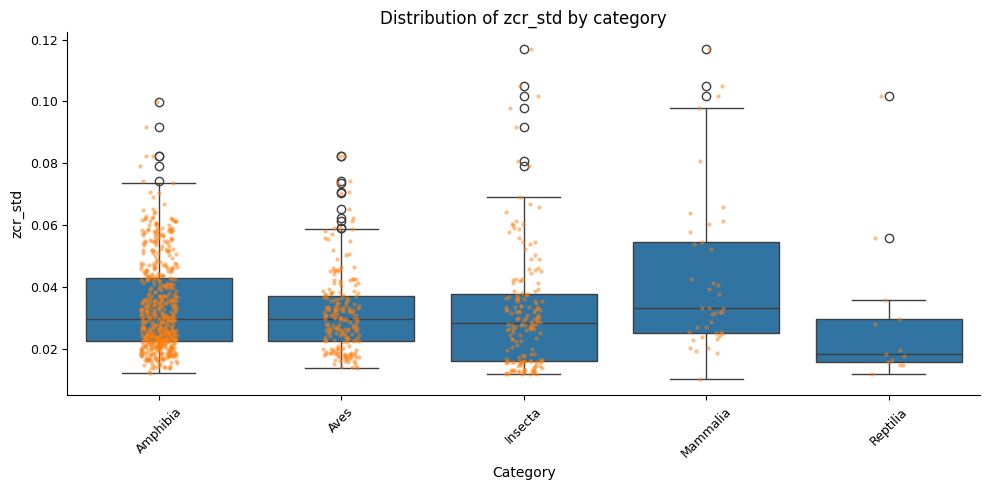

In [43]:
viz.plot_feature_distribution(data_train_soundscapes, "zcr_std")
# viz.plot_feature_distribution(data_train_soundscapes, "")

Principle Component Analysis

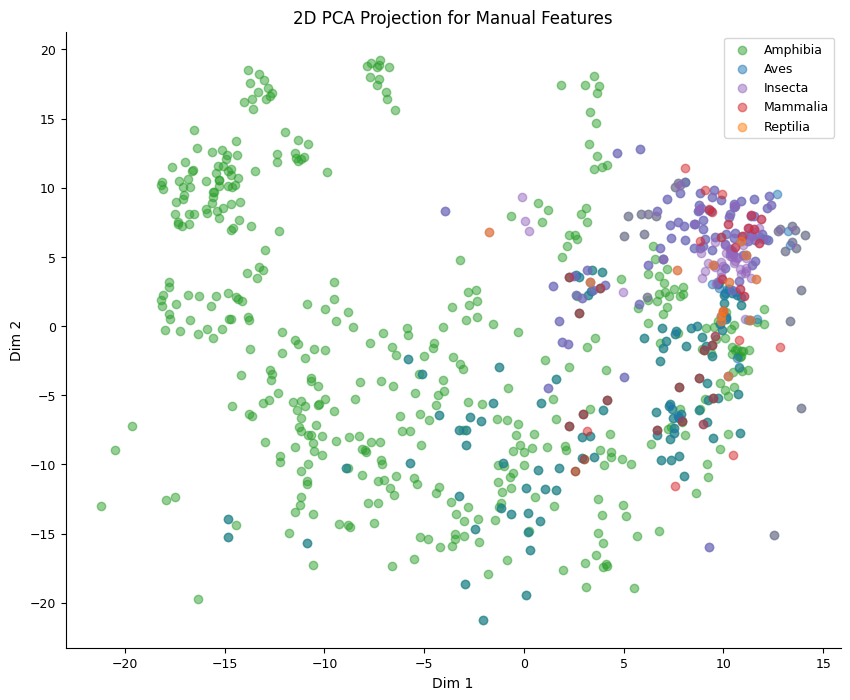

In [44]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Features and labels
X = data_train_soundscapes["X"]
y = data_train_soundscapes["y_class"]

# Standardization + PCA pipeline
pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=10),
)

# Transformed features
X_pca = pca_pipeline.fit_transform(X)

viz.plot_dim_reduction(
    X_pca,
    y,
    title="2D PCA Projection for Manual Features",
    all_class_combinations=False,
    save_file="../results/figures/pca-features.pdf",
)

<Axes: title={'center': 'Scree Plot for PCA on Manual Features'}, xlabel='Principal Component', ylabel='Explained Variance Ratio'>

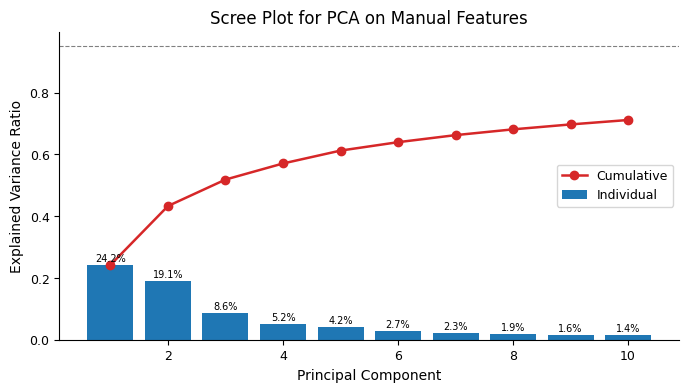

In [45]:
viz.plot_scree(
    pca_pipeline.named_steps["pca"].explained_variance_ratio_,
    "Scree Plot for PCA on Manual Features",
    save_file="../results/figures/scree-plot-manual.pdf",
)

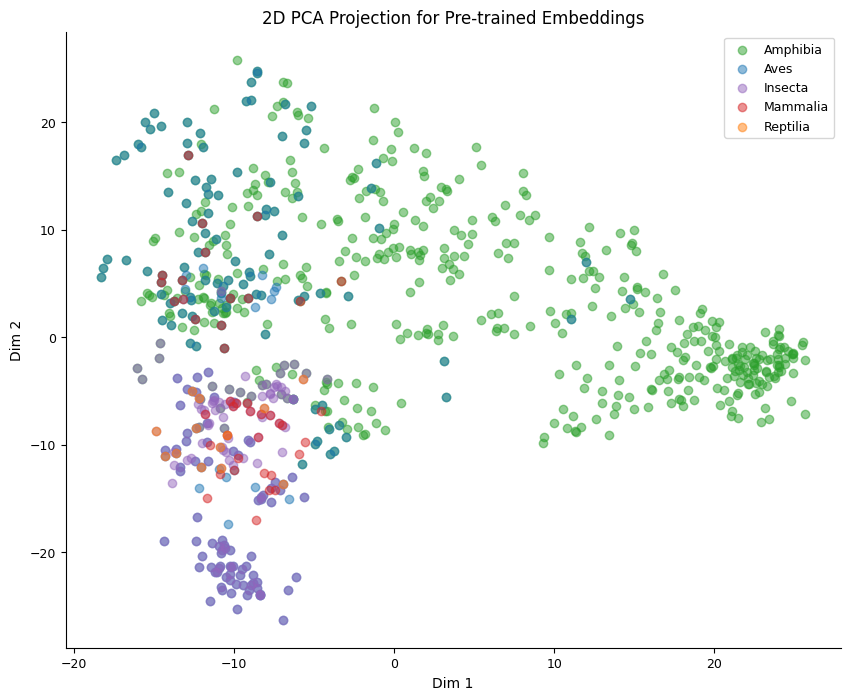

In [46]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Features and labels
X = data_train_embeddings["X"]
y = data_train_embeddings["y_class"]

# Standardization + PCA pipeline
pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=10),
)

# Transformed features
X_pca = pca_pipeline.fit_transform(X)

viz.plot_dim_reduction(
    X_pca,
    y,
    title="2D PCA Projection for Pre-trained Embeddings",
    all_class_combinations=False,
    save_file="../results/figures/pca-embeddings.pdf",
)

<Axes: title={'center': 'Scree Plot for PCA on Pre-trained Embeddings'}, xlabel='Principal Component', ylabel='Explained Variance Ratio'>

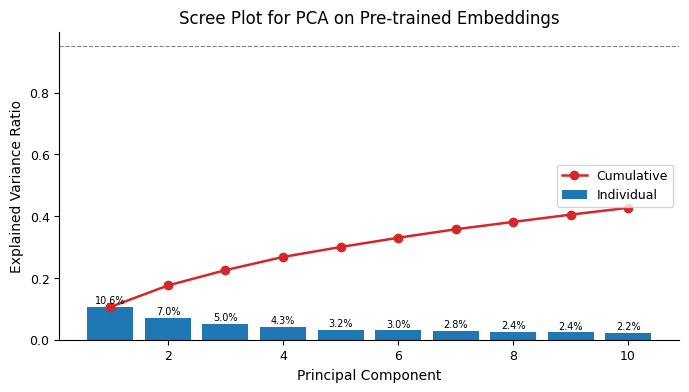

In [47]:
viz.plot_scree(
    pca_pipeline.named_steps["pca"].explained_variance_ratio_,
    "Scree Plot for PCA on Pre-trained Embeddings",
    save_file="../results/figures/scree-plot-embeddings.pdf",
)

# UMAP

/Users/milosoundjian/Documents/sorbonne/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


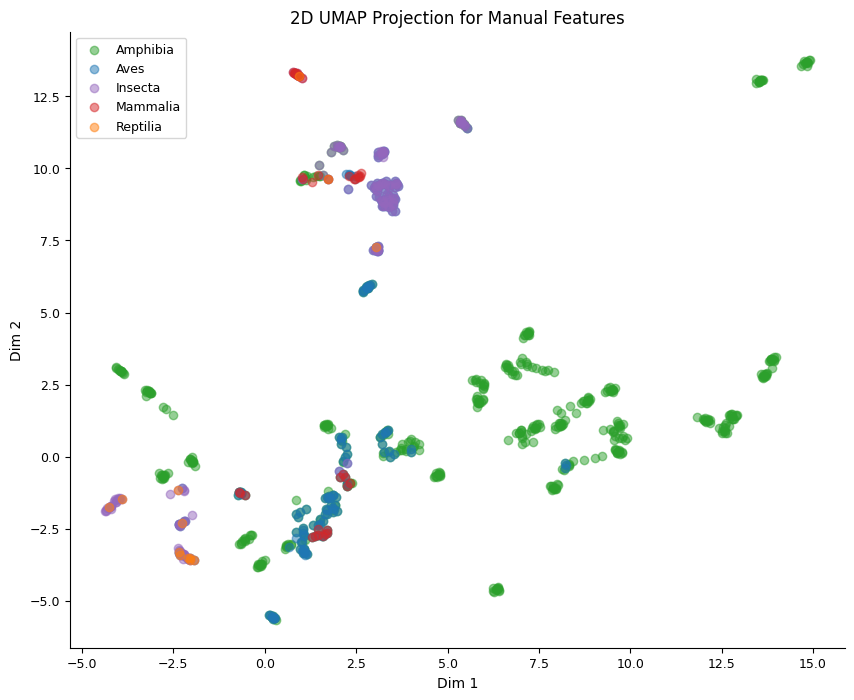

In [87]:
from umap import UMAP

# Features and labels
X = data_train_soundscapes["X"]
y = data_train_soundscapes["y_class"]

# Standardization + UMAP pipeline
umap_pipeline = make_pipeline(
    StandardScaler(),
    UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.2,
        metric="euclidean",
        random_state=42,
    ),
)

# Transformed features
X_umap = umap_pipeline.fit_transform(X)

viz.plot_dim_reduction(
    X_umap,
    y,
    title="2D UMAP Projection for Manual Features",
    all_class_combinations=False,
    save_file="../results/figures/umap-manual.pdf",
)

/Users/milosoundjian/Documents/sorbonne/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


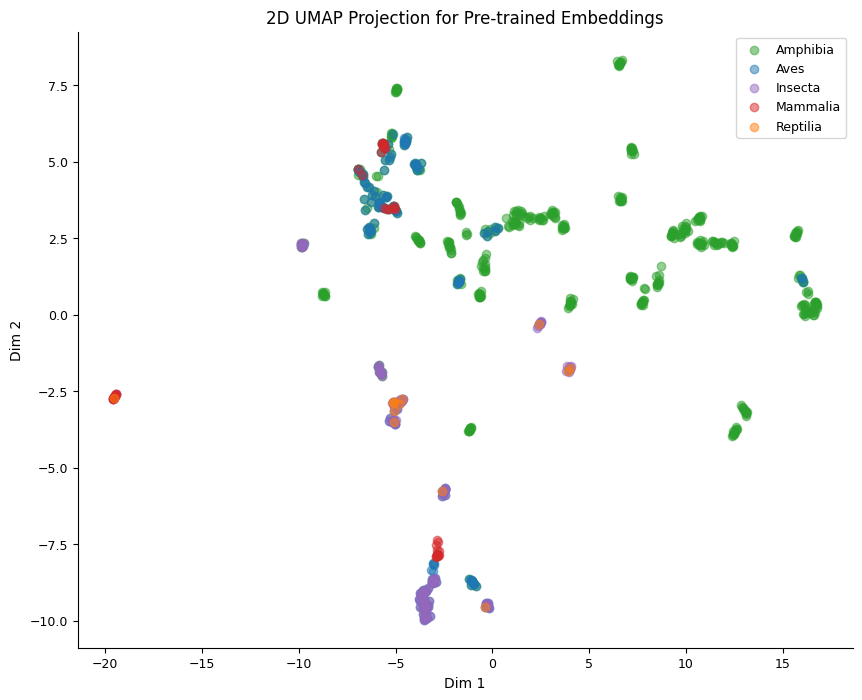

In [89]:
from umap import UMAP

# Features and labels
X = data_train_embeddings["X"]
y = data_train_embeddings["y_class"]

# Standardization + UMAP pipeline
umap_pipeline = make_pipeline(
    StandardScaler(),
    UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.2,
        metric="cosine",
        random_state=42,
    ),
)

# Transformed features
X_umap = umap_pipeline.fit_transform(X)

viz.plot_dim_reduction(
    X_umap,
    y,
    title="2D UMAP Projection for Pre-trained Embeddings",
    all_class_combinations=False,
    save_file="../results/figures/umap-embeddings.pdf",
)

# Check which species are close to Pantanal

6574 / 35549 selected


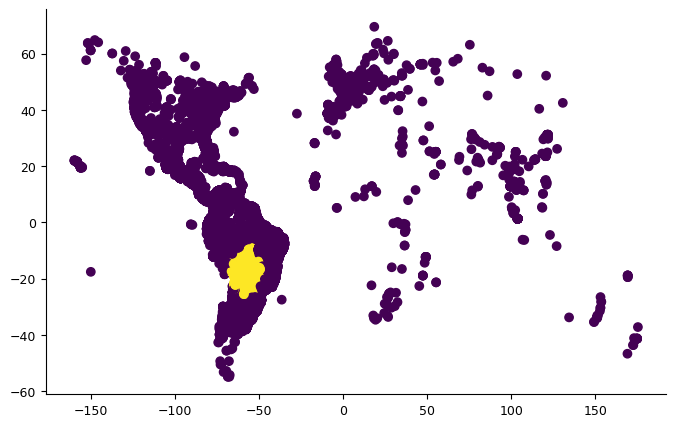

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97710/3370963405.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts_train = data_train["y_primary"][df["relevant_location"]].sum(axis=0) / data_train["y_primary"].sum(axis=0)


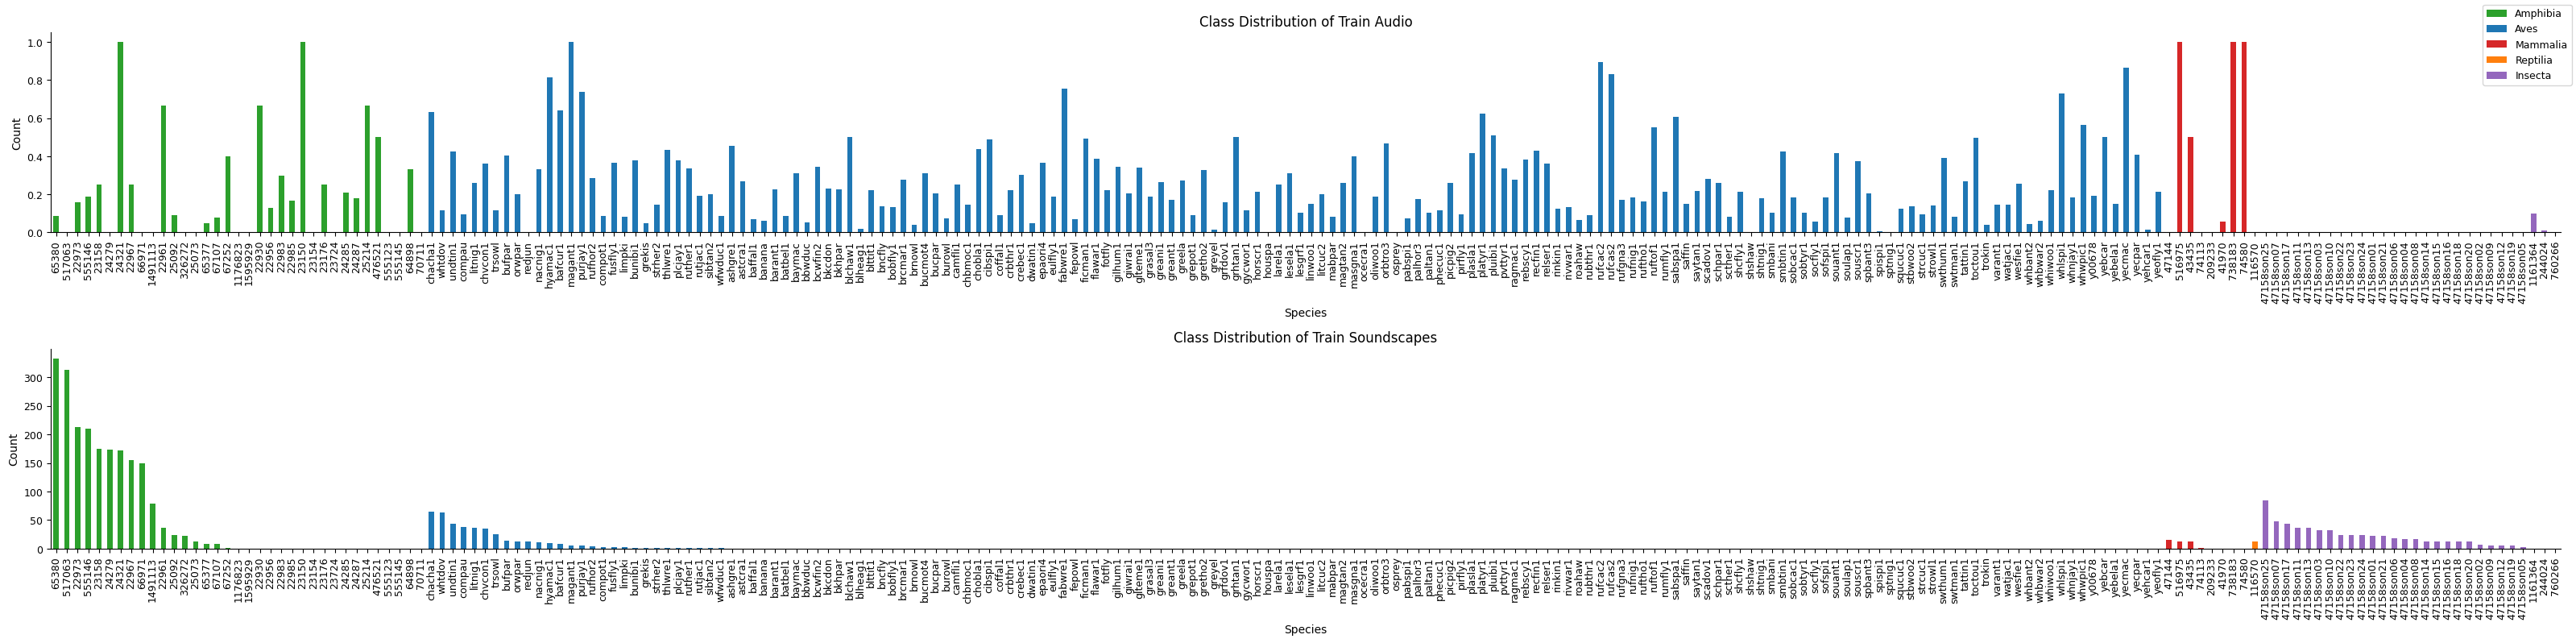

In [ ]:
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from bioacoustics.data import load_metadata

df = data_train["metadata"].copy()

# Pantanal centroid (approx)
pantanal_center = (-17.5, -57.5)
GEO_RADIUS = 1000


def close_to_pantanal(lat, lon, threshold_km=GEO_RADIUS):
    return geodesic((lat, lon), pantanal_center).km < threshold_km


df["relevant_location"] = df.apply(
    lambda r: close_to_pantanal(r["latitude"], r["longitude"]), axis=1
)
print(f"{df['relevant_location'].sum()} / {len(df)} selected")


plt.scatter(df["longitude"], df["latitude"], c=df["relevant_location"])
plt.show()
counts_train = data_train["y_primary"][df["relevant_location"]].sum(
    axis=0
) / data_train["y_primary"].sum(axis=0)
counts_sound = data_train_soundscapes["y_primary"].sum(axis=0)

_, _, df_taxonomy = load_metadata()
primary_to_class = dict(zip(df_taxonomy["primary_label"], df_taxonomy["class_name"]))
viz.plot_species_distribution(counts_train, counts_sound, primary_to_class)